In [29]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import pickle

df = pd.read_csv("./data/titanic_clean.csv")
df.head(5)

df.info()
df.isna().sum()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    str    
 4   Sex          889 non-null    str    
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    str    
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.5 KB
<class 'pandas.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64

In [5]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Embarked           str
dtype: object

In [6]:
df.drop(columns=["PassengerId","Name","Ticket"], inplace=True)
df.head(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [7]:

df_str = df.select_dtypes(include="str")
cat_features = ["Sex","Embarked"]
# df_str.groupby("Embarked").
one_hot_encoder =OneHotEncoder( sparse_output=False, handle_unknown="ignore")
one_hot_encoder_sp =OneHotEncoder( sparse_output=True, handle_unknown="ignore")

one_hot_encoder.fit(df[cat_features])
one_hot_encoder_sp.fit(df[cat_features])
one_hot_encoder

,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infreque

In [8]:
colums_features = one_hot_encoder.get_feature_names_out(cat_features)
colums_features_sp = one_hot_encoder_sp.get_feature_names_out(cat_features)
colums_features
# type(colums_features)

array(['Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype=object)

In [9]:
transformed_categorical_features = one_hot_encoder.transform(df[cat_features])
transformed_categorical_features_sp = one_hot_encoder_sp.transform(df[cat_features])
transformed_categorical_features



array([[0., 1., 0., 0., 1.],
       [1., 0., 1., 0., 0.],
       [1., 0., 0., 0., 1.],
       ...,
       [1., 0., 0., 0., 1.],
       [0., 1., 1., 0., 0.],
       [0., 1., 0., 1., 0.]], shape=(889, 5))

In [10]:
df_transformed_one_hot = pd.DataFrame(transformed_categorical_features, columns=colums_features)
df_transformed_one_hot_sp = pd.DataFrame.sparse.from_spmatrix(transformed_categorical_features_sp, columns=colums_features_sp)
df_transformed_one_hot.head(5)
df_transformed_one_hot_sp.head(5)
df_transformed_one_hot_sp.info()

<class 'pandas.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype               
---  ------      --------------  -----               
 0   Sex_female  1 non-null      Sparse[float64, nan]
 1   Sex_male    1 non-null      Sparse[float64, nan]
 2   Embarked_C  1 non-null      Sparse[float64, nan]
 3   Embarked_Q  1 non-null      Sparse[float64, nan]
 4   Embarked_S  1 non-null      Sparse[float64, nan]
dtypes: Sparse[float64, nan](5)
memory usage: 21.0 KB


In [11]:
df.drop(columns= cat_features, inplace=True)
df_final = df.join(df_transformed_one_hot)
# df = pd.concat([df, df_transformed_one_hot], axis=1)
df_final.head(5)

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,0.0,1.0,0.0,0.0,1.0
1,1,1,38.0,1,0,71.2833,1.0,0.0,1.0,0.0,0.0
2,1,3,26.0,0,0,7.9250,1.0,0.0,0.0,0.0,1.0
3,1,1,35.0,1,0,53.1000,1.0,0.0,0.0,0.0,1.0
4,0,3,35.0,0,0,8.0500,0.0,1.0,0.0,0.0,1.0


In [12]:
df_final.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,0.382452,2.311586,29.535624,0.524184,0.382452,32.096681,0.350956,0.649044,0.188976,0.086614,0.724409
std,0.486260,0.834700,14.527483,1.103705,0.806761,49.697504,0.477538,0.477538,0.391710,0.281427,0.447063
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.000000,0.000000,0.000000,7.895800,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000,1.000000,0.000000,0.000000,1.000000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,1.000000,1.000000,0.000000,0.000000,1.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000,1.000000,1.000000,1.000000,1.000000


In [13]:
colums_to_scale = ["Age","SibSp","Parch","Fare","Pclass"]
scaler = MinMaxScaler(clip=True)
scaler.fit(df[colums_to_scale])
# scaled_features = scaler.transform(df[colums_to_scale])
df_final[colums_to_scale] = scaler.fit_transform(df[colums_to_scale])
df_final.head(5)

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,1.0,0.271174,0.125,0.0,0.014151,0.0,1.0,0.0,0.0,1.0
1,1,0.0,0.472229,0.125,0.0,0.139136,1.0,0.0,1.0,0.0,0.0
2,1,1.0,0.321438,0.000,0.0,0.015469,1.0,0.0,0.0,0.0,1.0
3,1,0.0,0.434531,0.125,0.0,0.103644,1.0,0.0,0.0,0.0,1.0
4,0,1.0,0.434531,0.000,0.0,0.015713,0.0,1.0,0.0,0.0,1.0


In [14]:
df_final.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,0.382452,0.655793,0.365866,0.065523,0.063742,0.062649,0.350956,0.649044,0.188976,0.086614,0.724409
std,0.486260,0.417350,0.182552,0.137963,0.134460,0.097003,0.477538,0.477538,0.391710,0.281427,0.447063
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.500000,0.246042,0.000000,0.000000,0.015412,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,0.346569,0.000000,0.000000,0.028213,0.000000,1.000000,0.000000,0.000000,1.000000
75%,1.000000,1.000000,0.472229,0.125000,0.000000,0.060508,1.000000,1.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [15]:
scaler.transform([[3,1,0,7.10,3]])

/Users/qiyunge/winMac/SoftwareDev/LaselleCollege/3_C2_gestion_de_données_avancé/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([[0.03242021, 0.125     , 0.        , 0.01385828, 1.        ]])

In [16]:
pickle_path = Path("./data/scaler.pkl")
with open(pickle_path, "wb") as f:
    pickle.dump(scaler, f)

scaler_loaded = pickle.load(open(pickle_path, "rb"))

In [17]:

df_X = df_final.drop(columns=["Survived"])

df_y = df_final["Survived"]
train_X, test_X, train_y, test_y = train_test_split(df_X, df_y, test_size=0.2, random_state=42)

train_X.info()


<class 'pandas.DataFrame'>
Index: 711 entries, 707 to 102
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      711 non-null    float64
 1   Age         711 non-null    float64
 2   SibSp       711 non-null    float64
 3   Parch       711 non-null    float64
 4   Fare        711 non-null    float64
 5   Sex_female  711 non-null    float64
 6   Sex_male    711 non-null    float64
 7   Embarked_C  711 non-null    float64
 8   Embarked_Q  711 non-null    float64
 9   Embarked_S  711 non-null    float64
dtypes: float64(10)
memory usage: 61.1 KB


In [18]:
test_X.info()


<class 'pandas.DataFrame'>
Index: 178 entries, 280 to 10
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      178 non-null    float64
 1   Age         178 non-null    float64
 2   SibSp       178 non-null    float64
 3   Parch       178 non-null    float64
 4   Fare        178 non-null    float64
 5   Sex_female  178 non-null    float64
 6   Sex_male    178 non-null    float64
 7   Embarked_C  178 non-null    float64
 8   Embarked_Q  178 non-null    float64
 9   Embarked_S  178 non-null    float64
dtypes: float64(10)
memory usage: 15.3 KB


In [19]:
model = MLPClassifier(hidden_layer_sizes=(40,20,10),
                    max_iter=2000, 
                    random_state=40, 
                    verbose=True, 
                    solver="adam", 
                    early_stopping=True,
                    validation_fraction=0.2,
                    
                    n_iter_no_change=10)
model.fit(train_X, train_y)
model.score(test_X, test_y)

Iteration 1, loss = 0.87886517
Validation score: 0.384615
Iteration 2, loss = 0.83790257
Validation score: 0.384615
Iteration 3, loss = 0.79994678
Validation score: 0.384615
Iteration 4, loss = 0.76555156
Validation score: 0.384615
Iteration 5, loss = 0.73508264
Validation score: 0.384615
Iteration 6, loss = 0.70552172
Validation score: 0.405594
Iteration 7, loss = 0.67864659
Validation score: 0.713287
Iteration 8, loss = 0.65261864
Validation score: 0.727273
Iteration 9, loss = 0.63105887
Validation score: 0.741259
Iteration 10, loss = 0.60986421
Validation score: 0.776224
Iteration 11, loss = 0.59287806
Validation score: 0.790210
Iteration 12, loss = 0.57707374
Validation score: 0.825175
Iteration 13, loss = 0.56351030
Validation score: 0.839161
Iteration 14, loss = 0.55135204
Validation score: 0.825175
Iteration 15, loss = 0.54058700
Validation score: 0.825175
Iteration 16, loss = 0.53054089
Validation score: 0.825175
Iteration 17, loss = 0.52093871
Validation score: 0.825175
Iterat

0.7808988764044944

In [20]:
predict = model.predict(test_X)
print(classification_report(test_y, predict))
print(confusion_matrix(test_y, predict))

              precision    recall  f1-score   support

           0       0.80      0.86      0.83       109
           1       0.75      0.65      0.70        69

    accuracy                           0.78       178
   macro avg       0.77      0.76      0.76       178
weighted avg       0.78      0.78      0.78       178

[[94 15]
 [24 45]]


In [21]:
model_2 = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation="relu",
    solver="adam",
    alpha=0.00001,
    verbose=True,
    learning_rate_init=0.001,
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.2,
    random_state=42
)
model_2.fit(train_X, train_y)
model_2.score(test_X, test_y)

Iteration 1, loss = 0.65981864
Validation score: 0.615385
Iteration 2, loss = 0.65313223
Validation score: 0.615385
Iteration 3, loss = 0.64662632
Validation score: 0.615385
Iteration 4, loss = 0.64022547
Validation score: 0.615385
Iteration 5, loss = 0.63373980
Validation score: 0.615385
Iteration 6, loss = 0.62788234
Validation score: 0.615385
Iteration 7, loss = 0.62194568
Validation score: 0.615385
Iteration 8, loss = 0.61614041
Validation score: 0.615385
Iteration 9, loss = 0.61047600
Validation score: 0.615385
Iteration 10, loss = 0.60503161
Validation score: 0.615385
Iteration 11, loss = 0.59980230
Validation score: 0.622378
Iteration 12, loss = 0.59466805
Validation score: 0.622378
Iteration 13, loss = 0.58982445
Validation score: 0.629371
Iteration 14, loss = 0.58508737
Validation score: 0.671329
Iteration 15, loss = 0.58034767
Validation score: 0.699301
Iteration 16, loss = 0.57574357
Validation score: 0.706294
Iteration 17, loss = 0.57141738
Validation score: 0.720280
Iterat

0.8089887640449438

              precision    recall  f1-score   support

           0       0.80      0.86      0.83       109
           1       0.75      0.65      0.70        69

    accuracy                           0.78       178
   macro avg       0.77      0.76      0.76       178
weighted avg       0.78      0.78      0.78       178

[[94 15]
 [24 45]]


Text(0.5, 1.0, 'Model 2')

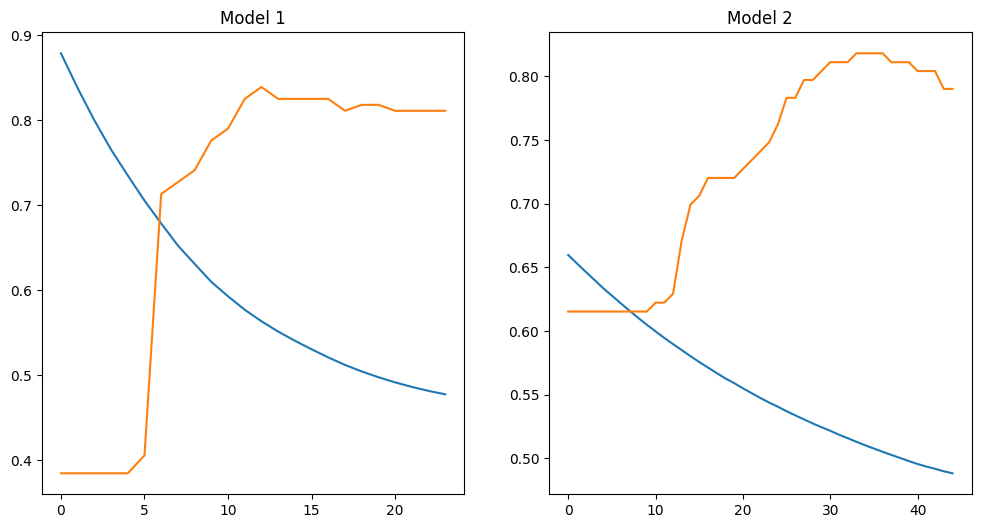

In [22]:
print(classification_report(test_y, model.predict(test_X)))
print(confusion_matrix(test_y, model.predict(test_X)))
model.loss_curve_
# plt.plot(model.loss_curve_)
figure, ax = plt.subplots(1,2, figsize=(12,6))
ax[0].plot(model.loss_curve_)
ax[0].plot(model.validation_scores_)
ax[0].set_title("Model 1")
ax[1].plot(model_2.loss_curve_)
ax[1].plot(model_2.validation_scores_)
ax[1].set_title("Model 2")  

In [25]:
corr = 0
wrong = 0

for i in range(len(test_y)):
    if test_y.iloc[i] == model.predict(test_X)[i]:
        corr += 1
    else:
        wrong += 1

print(f"Correct: {corr}, Wrong: {wrong}")

Correct: 139, Wrong: 39


In [28]:
cm = confusion_matrix(test_y, model.predict(test_X),labels= model.classes_)
cm

array([[94, 15],
       [24, 45]])

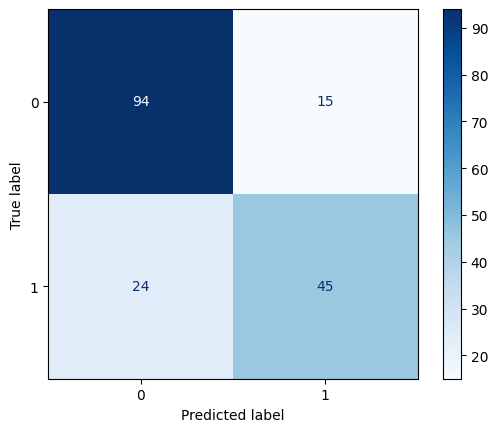

In [30]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [31]:
from sklearn.metrics import f1_score
f1 = f1_score(test_y, model.predict(test_X))
print(f"F1 Score: {f1}")

F1 Score: 0.6976744186046512


In [32]:
model.score(test_X, test_y)

0.7808988764044944

In [33]:
pickle_path_model = Path("./data/model_titanic.pkl")
with open(pickle_path_model, "wb") as f:
    pickle.dump(model, f)

In [34]:
model.feature_names_in_

array(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female',
       'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S'], dtype=object)

In [35]:
with open("./data/one_hot_encoder_titanic.pkl", "wb") as f:
    pickle.dump(one_hot_encoder, f)